In [1]:
import numpy as np
import pandas as pd
from keras.datasets import mnist
# X_train_image: 训练集特征 —— 图片
# y_train_label: 训练集标签 —— 数字 
# X_test_image： 测试集特征 —— 图片
# X_test_label: 测试集标签 —— 数字
(X_train_image, y_train_label), (X_test_image, y_test_label) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
print("数据集张量形状：", X_train_image.shape)
print("第一个数据样本：\n", X_train_image[0])

数据集张量形状： (60000, 28, 28)
第一个数据样本：
 [[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0

In [3]:
# 导入 One-hot 编码工具
from tensorflow.keras.utils import to_categorical
# 给训练标签增加一个维度
X_train = X_train_image.reshape(60000, 28, 28, 1)
# 给测试标签增加一个维度
X_test = X_test_image.reshape(10000, 28, 28, 1)
# 将训练特征转换为 One-hot 编码
y_train = to_categorical(y_train_label, 10)
# 将测试特征转换为 One-hot 编码
y_test = to_categorical(y_test_label, 10)
print("训练集张量形状：", X_train.shape)
print("第一个数据标签：", y_train[0])

训练集张量形状： (60000, 28, 28, 1)
第一个数据标签： [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [4]:
from keras import models
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
# 用序贯方式建立模型
model = models.Sequential()
# 添加 Conv2D 层，并指定输入数据样本张量类型
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
# 添加 MaxPooling2D 层
model.add(MaxPooling2D(pool_size=(2, 2)))
# 添加 Conv2D 层
model.add(Conv2D(64, (3, 3), activation='relu'))
# 添加 MaxPooling2D 层
model.add(MaxPooling2D(pool_size=(2, 2)))
# 添加 Dropout 层
model.add(Dropout(0.25 ))
# 展平
model.add(Flatten())
# 添加全连接层
model.add(Dense(128, activation='relu'))
# 添加 Dropout 层
model.add(Dropout(0.5))
# Softmax 分类激活，输出10 维分类码
model.add(Dense(10, activation='softmax'))
# 编译模型
model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
# 把训练集预留30%的数据作为验证集
model.fit(X_train, y_train, validation_split=0.3, epochs=5, batch_size=128)

Epoch 1/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - accuracy: 0.6870 - loss: 3.7059 - val_accuracy: 0.9692 - val_loss: 0.1104
Epoch 2/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 19s 58ms/step - accuracy: 0.9465 - loss: 0.1941 - val_accuracy: 0.9763 - val_loss: 0.0846
Epoch 3/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 19s 57ms/step - accuracy: 0.9647 - loss: 0.1296 - val_accuracy: 0.9769 - val_loss: 0.0891
Epoch 4/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 19s 56ms/step - accuracy: 0.9704 - loss: 0.1101 - val_accuracy: 0.9823 - val_loss: 0.0642
Epoch 5/5
329/329 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.9734 - loss: 0.0937 - val_accuracy: 0.9804 - val_loss: 0.0710


In [6]:
score = model.evaluate(X_test, y_test)
print('测试集预测准确率：', score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9756 - loss: 0.0845
测试集预测准确率： 0.9804999828338623


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
[6.1771559e-15 5.4100908e-13 2.5539006e-08 3.3413272e-10 3.8929908e-13
 7.6531265e-15 1.7096866e-19 1.0000000e+00 1.9166420e-13 3.2949943e-10] 转换一下格式得到： 7


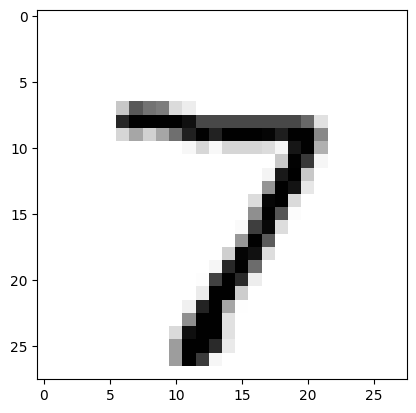

In [7]:
# 预测测试集第一个数据
pred = model.predict(X_test[0].reshape(1, 28, 28, 1))
# 把 One-hot 编码转换为数字
print(pred[0], "转换一下格式得到：", pred.argmax())
# 导入绘图工具包
import matplotlib.pyplot as plt
plt.imshow(X_test[0].reshape(28, 28), cmap='Greys')